# Homework 1 (20pt): Bayes Decision Theory, Cost-Sensitive Classification, and Naive Bayes

**ESE 561 — Theory of Artificial Intelligence**

- Part 1 (3pt): Bayes Risk and Cost-Sensitive Decisions
- Part 2 (8pt): Bayes/MAP estimator for continuous data, with a cost matrix
- Part 3 (9pt): Naive Bayes — a Bayesian spam filter, and classification metrics

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Part 1

Recall from lecture: a decision-making agent doesn't just want the most
*likely* outcome — it wants the *best* action, accounting for how costly
different kinds of mistakes are. This is Bayes decision theory (equivalently,
expected utility with $\text{Utility} = -\text{Cost}$).

Given posterior class probabilities $p(y=c\mid x)$ for $c=1,\ldots,C$, and a
**cost matrix** $\text{Cost}[a, c]$ = the cost of taking action $a$ when the
true class turns out to be $c$, the **Bayes risk** of action $a$ is its
expected cost:
$$
R(a\mid x) = \sum_{c=1}^{C} \text{Cost}[a,c]\, p(y=c\mid x).
$$
The Bayes-optimal decision rule picks the action that *minimizes* risk (i.e.
maximizes expected utility):
$$
a^*(x) = \underset{a}{\operatorname{argmin}}\; R(a\mid x).
$$
When the cost matrix is the plain 0/1 loss ($\text{Cost}[a,c] = 0$ if $a=c$,
else $1$), this collapses to ordinary MAP classification — cost-sensitive
decisions are the *general* case, and MAP is a special case.

The `bayes_risk` helper below implements this formula directly (it's given —
just a direct transcription of $R(a\mid x)$ above) and is used throughout the
rest of this part and in Part 3.

## Q1 (3pt) Derive and verify a cost-sensitive spam threshold

Consider a binary spam filter with actions $a\in\{\text{ham}, \text{spam}\}$
and true classes $c\in\{\text{ham},\text{spam}\}$. A **false positive**
(flagging a real email as spam — the user might miss something important)
costs $C_{FP}$; a **false negative** (letting spam through — merely
annoying) costs $C_{FN}$, with $C_{FP} > C_{FN}$. Correct decisions cost 0.

**By hand**, using the risk formula above with $p = p(\text{spam}\mid x)$,
show that the Bayes-optimal rule is:
$$
\text{predict spam} \iff p > \frac{C_{FP}}{C_{FP}+C_{FN}}.
$$
*(Write your derivation in the markdown cell below — this is graded.)*

**Your derivation:**

_(replace this with your work)_

Then, fill in `cost_matrix` for $C_{FP}=5,\ C_{FN}=1$ below and confirm your
formula numerically by sweeping $p$ from 0 to 1 and finding where
`bayes_risk` actually switches its decision.

In [ ]:
# GIVEN: a direct transcription of R(a|x) = sum_c Cost[a,c] p(y=c|x) above.
# You'll use this helper for Q1 below, and again in Part 3.
def bayes_risk(posteriors, cost_matrix):
    """
    Compute the Bayes risk of every action for every datapoint.

    Args:
        posteriors:  (n, C) array; posteriors[i, c] = p(y=c | x_i).
                     Each row sums to 1.
        cost_matrix: (n_actions, C) array; cost_matrix[a, c] = cost of
                     taking action a when the true class is c.

    Returns:
        risks:   (n, n_actions) array; risks[i, a] = expected cost (risk)
                 of action a on point i.
        actions: (n,) array; the Bayes-optimal (minimum-risk) action index
                 for each point.
    """
    risks = posteriors @ cost_matrix.T
    actions = np.argmin(risks, axis=1)
    return risks, actions


# demonstration: symmetric 0/1 cost reduces to plain MAP, as the theory above claims
rng = np.random.default_rng(0)
posteriors = rng.dirichlet(np.ones(4), size=20)
symmetric_cost = 1 - np.eye(4)
risks, actions = bayes_risk(posteriors, symmetric_cost)
map_actions = np.argmax(posteriors, axis=1)
assert np.array_equal(actions, map_actions), "symmetric 0/1 cost should match plain MAP"
print("Confirmed: with symmetric 0/1 cost, bayes_risk's decisions match plain MAP.")

In [ ]:
C_FP, C_FN = 5.0, 1.0
# actions: 0 = predict ham, 1 = predict spam
# classes: 0 = ham,         1 = spam
cost_matrix = #<YOUR CODE HERE -- (2,2) cost matrix using C_FP and C_FN>

threshold_derived = #<YOUR CODE HERE -- your formula from above, in terms of C_FP, C_FN>
print("derived threshold t* =", threshold_derived)

ps = np.linspace(0, 1, 2001)
posteriors_grid = np.stack([1 - ps, ps], axis=1)
risks_grid, actions_grid = bayes_risk(posteriors_grid, cost_matrix)

switch_idx = np.argmax(actions_grid == 1)
empirical_threshold = ps[switch_idx]
print("empirical switch point:", round(empirical_threshold, 4))
assert np.isclose(empirical_threshold, threshold_derived, atol=1e-3), \
    "empirical switch point should match your derived formula"
print("Matches the derived formula.")

plt.figure(figsize=(5.5, 4))
plt.plot(ps, risks_grid[:, 0], label="risk(predict ham)")
plt.plot(ps, risks_grid[:, 1], label="risk(predict spam)")
plt.axvline(threshold_derived, color="k", linestyle="--", label=f"t*={threshold_derived:.3f}")
plt.xlabel("p(spam | x)"); plt.ylabel("expected cost")
plt.title(f"Bayes risk vs. posterior (C_FP={C_FP}, C_FN={C_FN})")
plt.legend(); plt.tight_layout(); plt.show()

Keep this threshold formula in mind — you will use it again at the very end
of Part 3, to tune a real classifier's decision threshold.

# Part 2
In this Question you will work with a dataset from Ch.2 in *Classification, Parameter Estimation and State
Estimation: An Engineering Approach Using MATLAB* by
R. Duin, F. van der Heijden, D. de Ridder, and D. M.
J. Tax (https://go.exlibris.link/Y6BQ8cJ5).

In your solution, you should get similar decision boundaries as in the textbook:

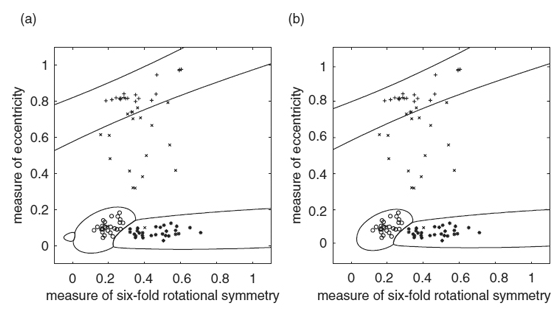

In [ ]:
# Loads the real course dataset
data = pd.read_csv("https://raw.githubusercontent.com/anton-selitskiy/RIT_ML/main/2023_fall/data_bnrs.csv", header=None)
print(f"Loaded the real dataset: {data.shape}")

In [ ]:
data.head()

In [ ]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.scatter(X_test[:, 0], X_test[:, 1], marker="x")
plt.title("Training points (dots) and test points (x)")
plt.show()

From the conditional probability formula, we know that
$$
p(y=c|x) = \frac{p(x, y=c)}{p(x)} = \frac{p(x|y=c)p(y=c)}{p(x)}, \quad c=1,2,3,4.
$$

Because the denominator doesn't depend on $c,$
$$
a(x) = \underset{c}{argmax}\ p(y=c|x) = \underset{c}{argmax}\ p(x|y=c)p(y=c).
$$

We will assume that conditional distribution $p(x|y=c)\sim N(\mu_c,\Sigma_c)$; you can use `multivariate_normal` from `scipy.stats` to calculate this value for the entire matrix $X$ with datapoints in rows $X[i,:]$ as follows: `multivariate_normal(X, mean=, cov=)`.

For the cost function, you can use the following decision rule (this is exactly the Bayes-risk rule from Part 1, applied here with $C=4$ classes):
$$
a(x) = argmin\ \text{Cost_Matrix}\cdot \begin{bmatrix}p(y=1|x)\\ p(y=2|x) \\ p(y=3|x)\\ p(y=4|x)\end{bmatrix} = argmin\ \text{Cost_Matrix}\cdot \begin{bmatrix}p(x|y=1)p(y=1)\\ p(x|y=2)p(y=2) \\ p(x|y=3)p(y=3)\\ p(x|y=4)p(y=4)\end{bmatrix}.
$$

**Note:** unlike for plain MAP (where the $p(x)$ denominator cancels and can be
ignored), the cost-weighted sum above needs the class posteriors to actually
be *normalized* probabilities, not just proportional scores — normalize
before applying the cost matrix.

## Q2 (8pt) Write the class `UserMAP` for maximum a posteriori estimation

In [ ]:
from scipy.stats import multivariate_normal

In [ ]:
class UserMAP():
    def __init__(self, cost=False):
        self.cost = cost

    def fit(self, X, y):
        """
        Calculate mean values and covariance matrices for each class.
        Calculate class distribution p(y).
        Store them as self. variables
        """
        pass

    def posterior(self, X):
        """
        Calculate posterior probabilities and return argmax
        """
        pass

    def posterior_cost(self, X):
        """
        Given the cost matrix and posterior probabilities, predict the class
        """
        cost_matrix = np.array([
            [-0.20, 0.07, 0.07, 0.07],
            [ 0.07,-0.15, 0.07, 0.07],
            [ 0.07, 0.07,-0.05, 0.07],
            [ 0.03, 0.03, 0.03, 0.03]])
        pass

    def predict(self, X):
        if self.cost == True:
            return self.posterior_cost(X)
        return self.posterior(X)


clf = UserMAP().fit(X_train, y_train)
print("plain-MAP test accuracy:", round(np.mean(clf.predict(X_test) == y_test), 3))

In [ ]:
# mlxtend gives a nice decision-region plot; fall back to a small hand-rolled
# version if it isn't installed in your environment.
from mlxtend.plotting import plot_decision_regions

In [ ]:
plt.figure(figsize=(5, 4))
plot_decision_regions(X_test, y_test, clf)
plt.title("Plain MAP decision regions")
plt.show()

In [ ]:
clf_cost = UserMAP(cost=True).fit(X_train, y_train)

plt.figure(figsize=(5, 4))
plot_decision_regions(X_test, y_test, clf_cost)
plt.title("Cost-sensitive MAP decision regions")
plt.show()

Compare the two plots above: the cost matrix penalizes some misclassifications
much more than others (look at its diagonal), so the cost-sensitive boundaries
should shrink the regions assigned to the "expensive to get wrong" classes,
even though doing so may lower *raw accuracy* — this is the whole point of
Part 1's distinction between minimizing error rate (plain MAP / 0-1 loss) and
minimizing expected cost (Bayes risk).

# Part 3

In this Question, you will apply a Naive Bayes classifier to build a spam filter. We use the *Enron email dataset* (https://www.kaggle.com/datasets/venky73/spam-mails-dataset?select=spam_ham_dataset.csv), a large collection of real emails from the Enron Corporation, labeled spam/ham.

In [ ]:
# Loads the real Enron spam/ham dataset via kagglehub (recommended -- works
# in Colab once you've added your (free) Kaggle API credentials: see
# https://github.com/Kaggle/kagglehub#authenticate). Falls back to a local
# spam_ham_dataset.csv if you downloaded it manually.
import kagglehub
_path = kagglehub.dataset_download("venky73/spam-mails-dataset")
data = pd.read_csv(f"{_path}/spam_ham_dataset.csv")
# data = pd.read_csv("spam_ham_dataset.csv")
print(f"Loaded via kagglehub: {data.shape}")

In [ ]:
from sklearn.model_selection import train_test_split
texts_train, texts_test, y_train, y_test = train_test_split(texts, target, test_size=0.5, random_state=42)

### Preprocessing and tokenization

### Solving it: bag of words

![img](http://www.novuslight.com/uploads/n/BagofWords.jpg)

Apply `CountVectorizer()` to the training data.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer()

In [ ]:
X_train_bow = vec.fit_transform(texts_train).toarray()
X_test_bow = vec.transform(texts_test).toarray()

Now you have the counts of the words from the bag of words in each e-mail.

__Naive Bayes:__ perhaps the simplest model that can solve your problem is the so called Naive Bayes Classifier.
It's a simple probabilistic model that assumes the independence of input features and computes counting probabilities.

If you don't remember the math behind Naive Bayes, read https://scikit-learn.org/stable/modules/naive_bayes.html to help refresh your memory. Done? Good! Now let's implement that :)

For every word we will calculate its frequency in spam and in ham, i.e. $p(word|y=0)$ and $p(word|y=1)$. To avoid divisions by zero, instead of the formula
$$
p(word|y) =\frac{\#word \text{ in class y}}{\text{total # words in class } y}
$$
use
$$
p(word|y) =\frac{\delta+\#word \text{ in class y}}{\delta\cdot\text{vocabulary length} + \text{total # words in class } y}
$$

## Q3 (9pt) Write the class for Naive Bayes

In [ ]:
delta = 1.0
class BinaryNaiveBayes:
#     delta = 1.0  # add this to all word counts to smoothe probabilities

    def fit(self, X, y):
        """
        Fit a NaiveBayes classifier for two classes
        :param X: [batch_size, vocab_size] of bag-of-words features
        :param y: [batch_size] of binary targets {0, 1}
        """
        # first, compute marginal probabilities of every class, p(y=c) for c = 0,1
        self.p_y = #(<YOUR CODE: probability of y=0 and of y=1 in this order>)


        # count occurences of each word in texts with label 1 and label 0 separately
        word_counts_positive = #<YOUR CODE HERE>
        word_counts_negative = #<YOUR CODE HERE>
        # ^-- both must be vectors of shape [vocab_size].

        # finally, lets use those counts to estimate p(x | y = c) for c = 0, 1

        #<YOUR CODE HERE>

        self.p_x_given_positive = #<...>

        self.p_x_given_negative = #<...>
        # both must be of shape [vocab_size]; and don't forget to add self.delta!

        return self

    def predict_scores(self, X):
        """
        :param X: [batch_size, vocab_size] of bag-of-words features
        :returns: a matrix of scores [batch_size, k] of scores for k-th class
        """
        # compute scores for positive and negative classes separately.
        # these scores should be proportional to log-probabilities of the respective target {0, 1}
        score_negative = X.dot(np.log(self.p_x_given_negative)) + np.log(self.p_y[0])
        score_positive = X.dot(np.log(self.p_x_given_positive)) + np.log(self.p_y[1])
        return np.stack([score_negative, score_positive], axis=-1)

    def predict(self, X):
        return self.predict_scores(X).argmax(axis=-1)

In [ ]:
naive_model = BinaryNaiveBayes().fit(X_train_bow, y_train)

In [ ]:
assert naive_model.p_y.shape == (2,) and naive_model.p_y.sum() == 1
assert naive_model.p_x_given_positive.shape == naive_model.p_x_given_negative.shape == X_train_bow.shape[1:]
assert np.allclose(naive_model.p_x_given_positive.sum(), 1.0)
assert np.allclose(naive_model.p_x_given_negative.sum(), 1.0)
assert naive_model.p_x_given_negative.min() > 0, "did you forget to add delta?"
print("All BinaryNaiveBayes structural checks passed.")

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(5, 4))
for name, X, y, model in [
    ("train", X_train_bow, y_train, naive_model),
    ("test ", X_test_bow, y_test, naive_model)
]:
    proba = model.predict_scores(X)[:, 1] - model.predict_scores(X)[:, 0]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label="%s AUC=%.4f" % (name, auc))

plt.plot([0, 1], [0, 1], "--", color="black")
plt.legend(fontsize="large")
plt.grid()
plt.show()

test_accuracy = np.mean(naive_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.75, "Accuracy too low. There's likely a mistake in the code."
print("Well done!")

Okay, it definitely learned *something*. Now let's figure out what exactly it learned. The simplest way to do that is by highlighting which words have the greatest ratio of positive to negative probability or vice versa. (The log of that fraction is called *logit.*) Here are the top-25 words that have the __highest__ ratio of ${p(x_i | y=0)} \over {p(x_i | y=1)}$.

In [ ]:
bow_vocabulary = vec.get_feature_names_out()

In [ ]:
probability_ratio = 1 / (naive_model.p_x_given_positive / naive_model.p_x_given_negative)
top_negative_words = bow_vocabulary[np.argsort(probability_ratio)[:25]]
assert len(top_negative_words) == 25 and [isinstance(w, str) for w in top_negative_words]

for i, word in enumerate(top_negative_words):
    print(f"#{i}\t{word.rjust(10, ' ')}\t(ratio={probability_ratio[list(bow_vocabulary).index(word)]:.3f})")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, naive_model.predict(X_test_bow))
plt.show()

Now, let's do it with the built-in function and compare results.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = #<YOUR CODE HERE - train a built-in Naive Bayes>
np.mean(y_test==model.predict(X_test_bow))

Now let's try something less prehistoric: __Logistic Regression__. It turns out, if you're using silicon instead of an abacus, you can find model weights by optimizing the log-probability of the answer. Though, of course, you don't even need to write it by hand anymore. Let's sklearn it!

You can play with the parameter $C$ in `LogisticRegression` — it plays a similar role as in SVM, allowing slightly negative margins.

In [ ]:
from sklearn.linear_model import LogisticRegression
bow_model = #<YOUR CODE HERE - train a logistic regression>

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(5, 4))
for name, X, y, model in [
    ("train", X_train_bow, y_train, bow_model),
    ("test ", X_test_bow, y_test, bow_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label="%s AUC=%.4f" % (name, auc))

plt.plot([0, 1], [0, 1], "--", color="black")
plt.legend(fontsize="large")
plt.grid()
plt.show()

test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, bow_model.predict(X_test_bow))
plt.show()

## Q4 (1pt) Close the loop: apply Part 1's cost-sensitive threshold here

Both Naive Bayes and Logistic Regression above used the default decision rule
(predict spam iff predicted probability $>0.5$), which is only optimal under
a **symmetric** 0/1 cost — exactly the special case you proved in Part 1
reduces to plain MAP. A real spam filter usually should *not* use 0.5: a
false positive (losing a real email) is typically worse than a false
negative (one spam email slipping through).

Using your formula from Part 1 with $C_{FP}=5,\ C_{FN}=1$ (same as before),
compute the cost-optimal threshold, apply it to the **Logistic Regression**
model's predicted probabilities on the test set, and compare the resulting
confusion matrix to the default-threshold one above. Which type of error
(false positive vs. false negative) got rarer, and does that match what the
cost matrix rewards?

In [ ]:
t_star = #<YOUR CODE HERE -- cost-optimal threshold from Part 1, using C_FP and C_FN>
proba_test = bow_model.predict_proba(X_test_bow)[:, 1]
pred_cost_sensitive = #<YOUR CODE HERE -- threshold proba_test at t_star>

print(f"cost-optimal threshold (C_FP={C_FP}, C_FN={C_FN}): {t_star:.3f}")
print(f"accuracy at t*:   {np.mean(pred_cost_sensitive == y_test):.3f}")
print(f"accuracy at 0.5:  {np.mean(bow_model.predict(X_test_bow) == y_test):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(y_test, bow_model.predict(X_test_bow), ax=axes[0])
axes[0].set_title("default threshold (0.5)")
ConfusionMatrixDisplay.from_predictions(y_test, pred_cost_sensitive, ax=axes[1])
axes[1].set_title(f"cost-optimal threshold ({t_star:.3f})")
plt.tight_layout()
plt.show()

## Discussion (part of the 9pt for Part 3, allocate as you see fit)

1. In Q4, raising the threshold above 0.5 should trade some false negatives
   for false positives (or vice versa) — explain, from the cost matrix in
   Q1b, which direction the trade should go, and check that your Q4 result
   actually moved that way.
2. Naive Bayes assumes every word's occurrence is *conditionally independent*
   of every other word given the label. Give one concrete pair of words in an
   email where this assumption is clearly violated, and explain (in terms of
   the $p(x|y)$ factorization) why the model still tends to work well anyway.
3. (Open-ended) If Enron employees changed their writing style over time
   (e.g. to evade a spam filter), which of the two models — Naive Bayes or
   Logistic Regression — would you expect to degrade faster? And how one can update the models with new user's labels?